In [ ]:
import numpy as np

import matplotlib.pyplot as plt

import pdfs as pdfs_func

import seaborn as sns

import corner

In [32]:
import matplotlib as mpl
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
# rc('text', usetex=True)
mpl.rcParams['text.usetex'] = True
# mpl.rcParams['text.latex.preamble'] = [r'\usepackage{amsmath}']
mpl.rcParams['axes.linewidth'] = 0.5
plt.rcParams.update({'font.size': 18})
plt.rcParams.update({'font.weight': 'bold'})
plt.rcParams.update({'figure.subplot.top': 0.95})

mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5

plt.rcParams.update({'text.latex.preamble': r'\usepackage{amsfonts}'})

In [39]:
file=np.load('run_mock_lvk/run_1/samples.npz')

samples_gauss=file['samples_gauss']
samples_pl=file['samples_pl']

burn=1000

samples_gauss=samples_gauss[burn:].reshape(-1,3)
samples_pl=samples_pl[burn:].reshape(-1,4)

In [40]:
mlow=2
mhigh=100

m1_grid=np.linspace(mlow,mhigh,1000)


In [41]:
params_vary={}

params_vary['pl']=['log10_ampl_pl','alpha','mmin','mmax']
params_vary['gauss']=['log10_ampl_gauss','mu','sigma']

params_pl={}
for kpar,par in enumerate(params_vary['pl']):
    params_pl[par]=samples_pl[:,kpar][:,None]

params_gauss={}
for kpar,par in enumerate(params_vary['gauss']):
    params_gauss[par]=samples_gauss[:,kpar][:,None]

params_gauss['ampl']=10**params_gauss['log10_ampl_gauss']
params_pl['ampl']=10**params_pl['log10_ampl_pl']

nrep=len(samples_gauss)

ppds=pdfs_func.m1_pdf(m1_grid[None,:],params_gauss,params_pl,mlow=mlow*np.ones(nrep)[:,None],mhigh=mhigh*np.ones(nrep)[:,None])

In [56]:
file_data=np.load('data_mock_lvk.npz')

m1s_true=file_data['m1s_true_all']

file_max=np.load('true_parameters_lvk.npz')

params_gauss_true={}
params_pl_true={}

params_gauss_true['ampl']=np.array([10**file_max['p0'][0]])[None,:]
params_gauss_true['mu']=np.array([file_max['p0'][1]])[None,:]
params_gauss_true['sigma']=np.array([file_max['p0'][2]])[None,:]

params_pl_true['ampl']=np.array([10**file_max['p0'][3]])[None,:]
params_pl_true['alpha']=-np.array([file_max['p0'][4]])[None,:]
params_pl_true['mmin']=np.array([file_max['p0'][7]])[None,:]+np.array([file_max['p0'][5]])[None,:]
params_pl_true['mmax']=np.array([file_max['p0'][6]])[None,:]


pdf_true=pdfs_func.m1_pdf(m1_grid[None,:],params_gauss_true,params_pl_true,mlow=mlow*np.ones(1)[:,None],mhigh=mhigh*np.ones(1)[:,None])[0]*len(m1s_true)
# np.trapz(ppds,x=m1_grid,axis=1)

In [57]:
ppd_med=np.quantile(ppds,0.5,axis=0)
ppd_up=np.quantile(ppds,0.05,axis=0)
ppd_low=np.quantile(ppds,0.95,axis=0)

Text(0, 0.5, '$\\frac{{\\rm d}N}{{\\rm d}m_1} [M_{\\odot}^{-1}]$')

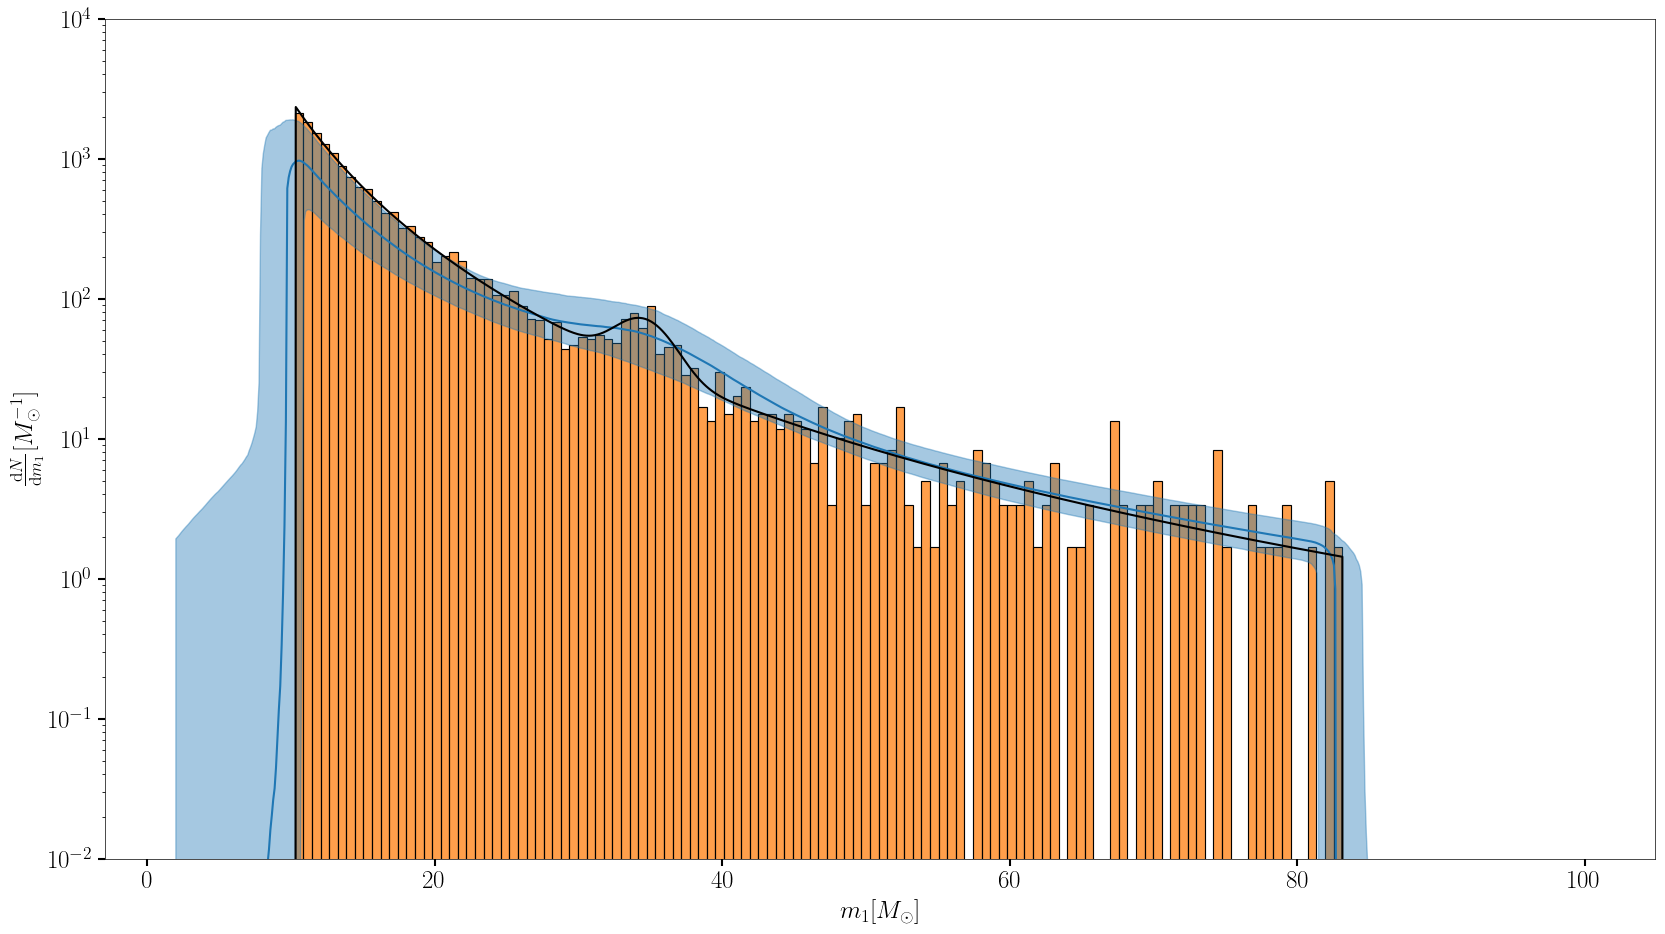

In [60]:
plt.figure(figsize=(20,10))

sns.histplot(m1s_true,stat='frequency',color='tab:orange')
plt.fill_between(m1_grid,ppd_low,ppd_up,alpha=0.4,color='tab:blue')
plt.plot(m1_grid,ppd_med,color='tab:blue')
plt.plot(m1_grid,pdf_true,c='k')



plt.yscale('log')
plt.ylim(1e-2,1e4)

plt.xlabel('$m_1 [M_{\\odot}]$')
plt.ylabel('$\\frac{{\\rm d}N}{{\\rm d}m_1} [M_{\\odot}^{-1}]$')

In [61]:
samples_all= np.concatenate((samples_gauss, samples_pl), axis=1)

[np.float64(2.2708669305453544), np.float64(34.467260516116596), np.float64(1.8667484132180945), np.float64(3.9829230543506093), np.float64(-3.548724658179429), np.float64(10.269198805173708), np.float64(83.14016351250682)]


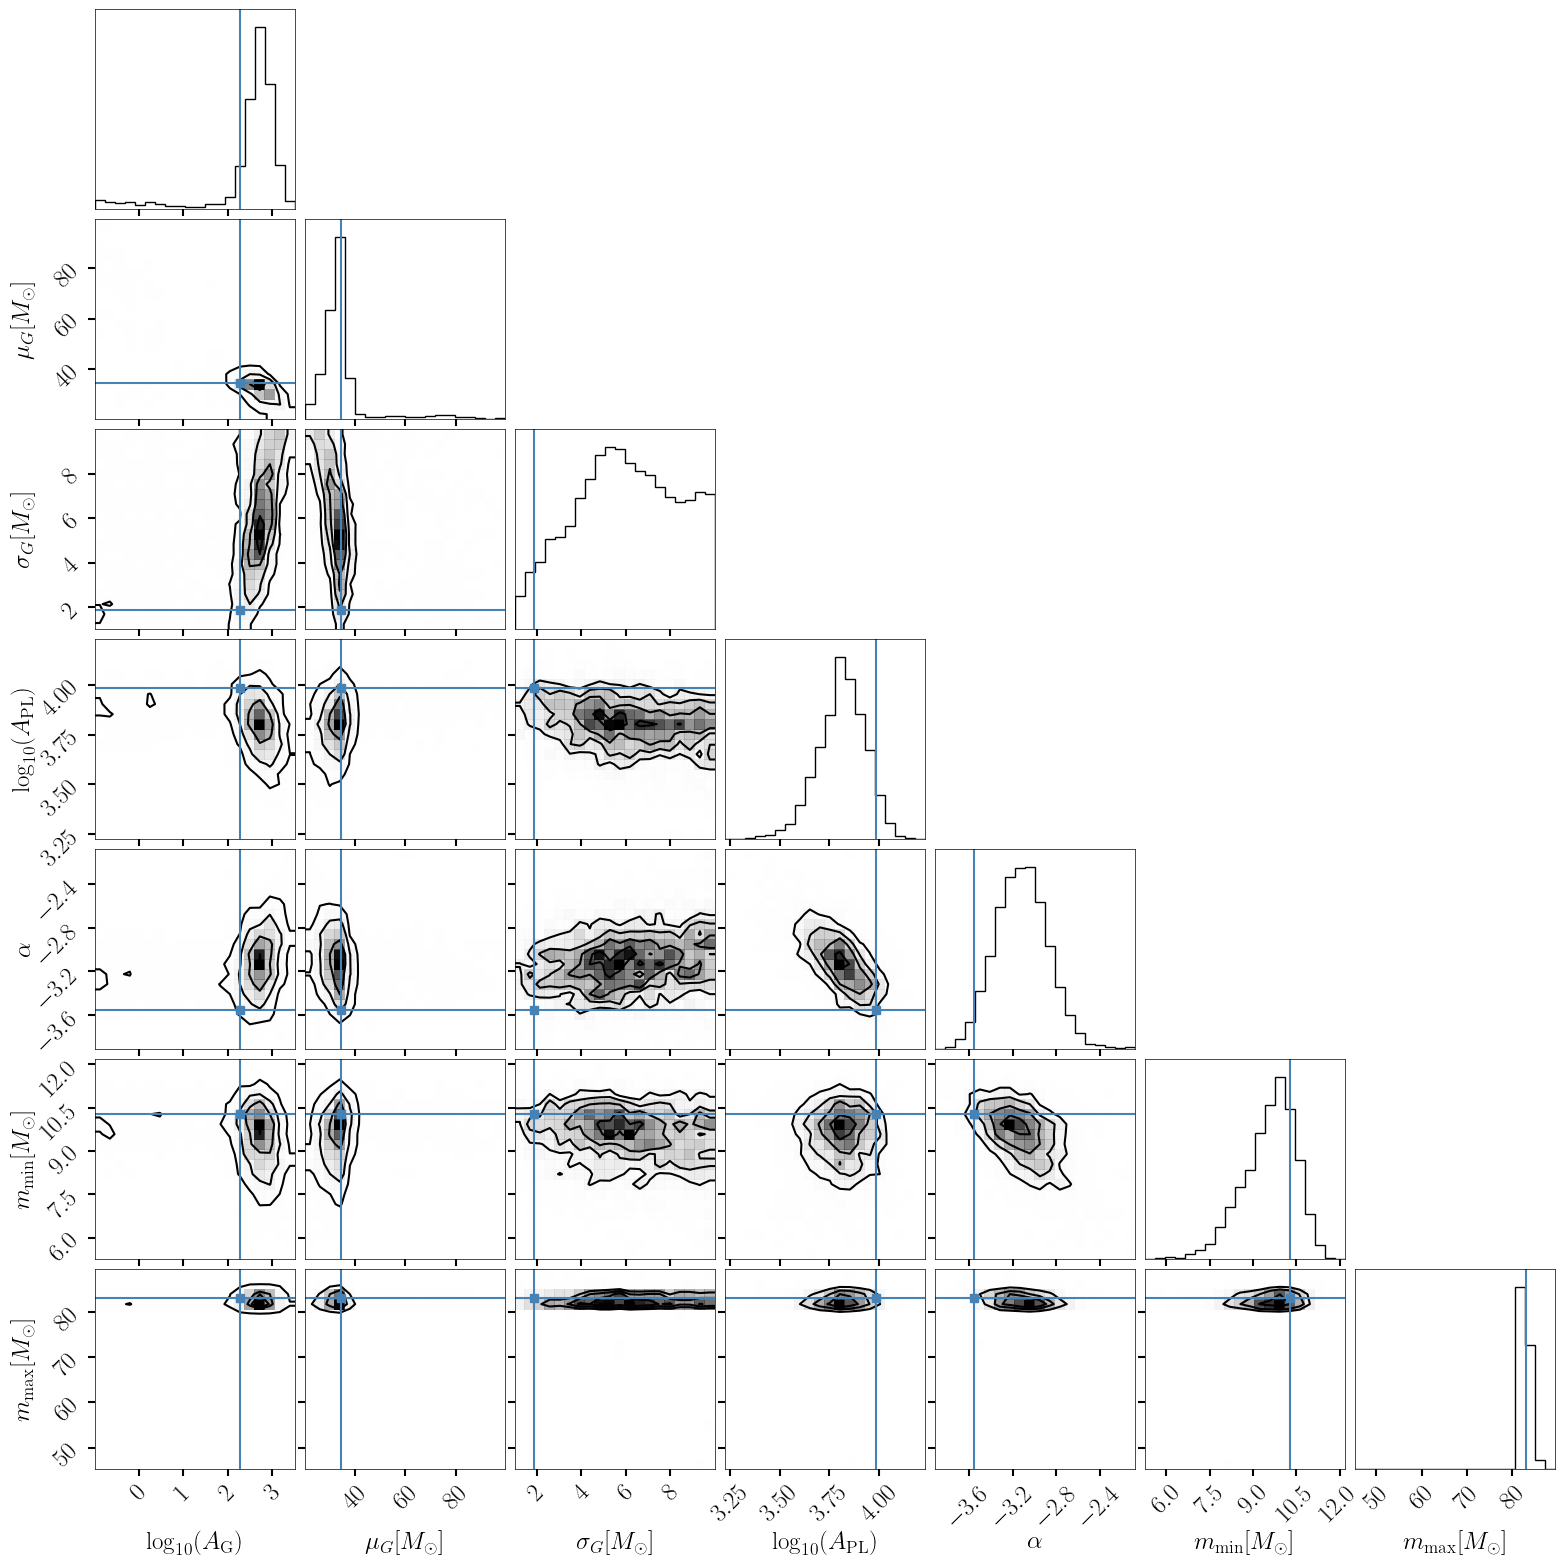

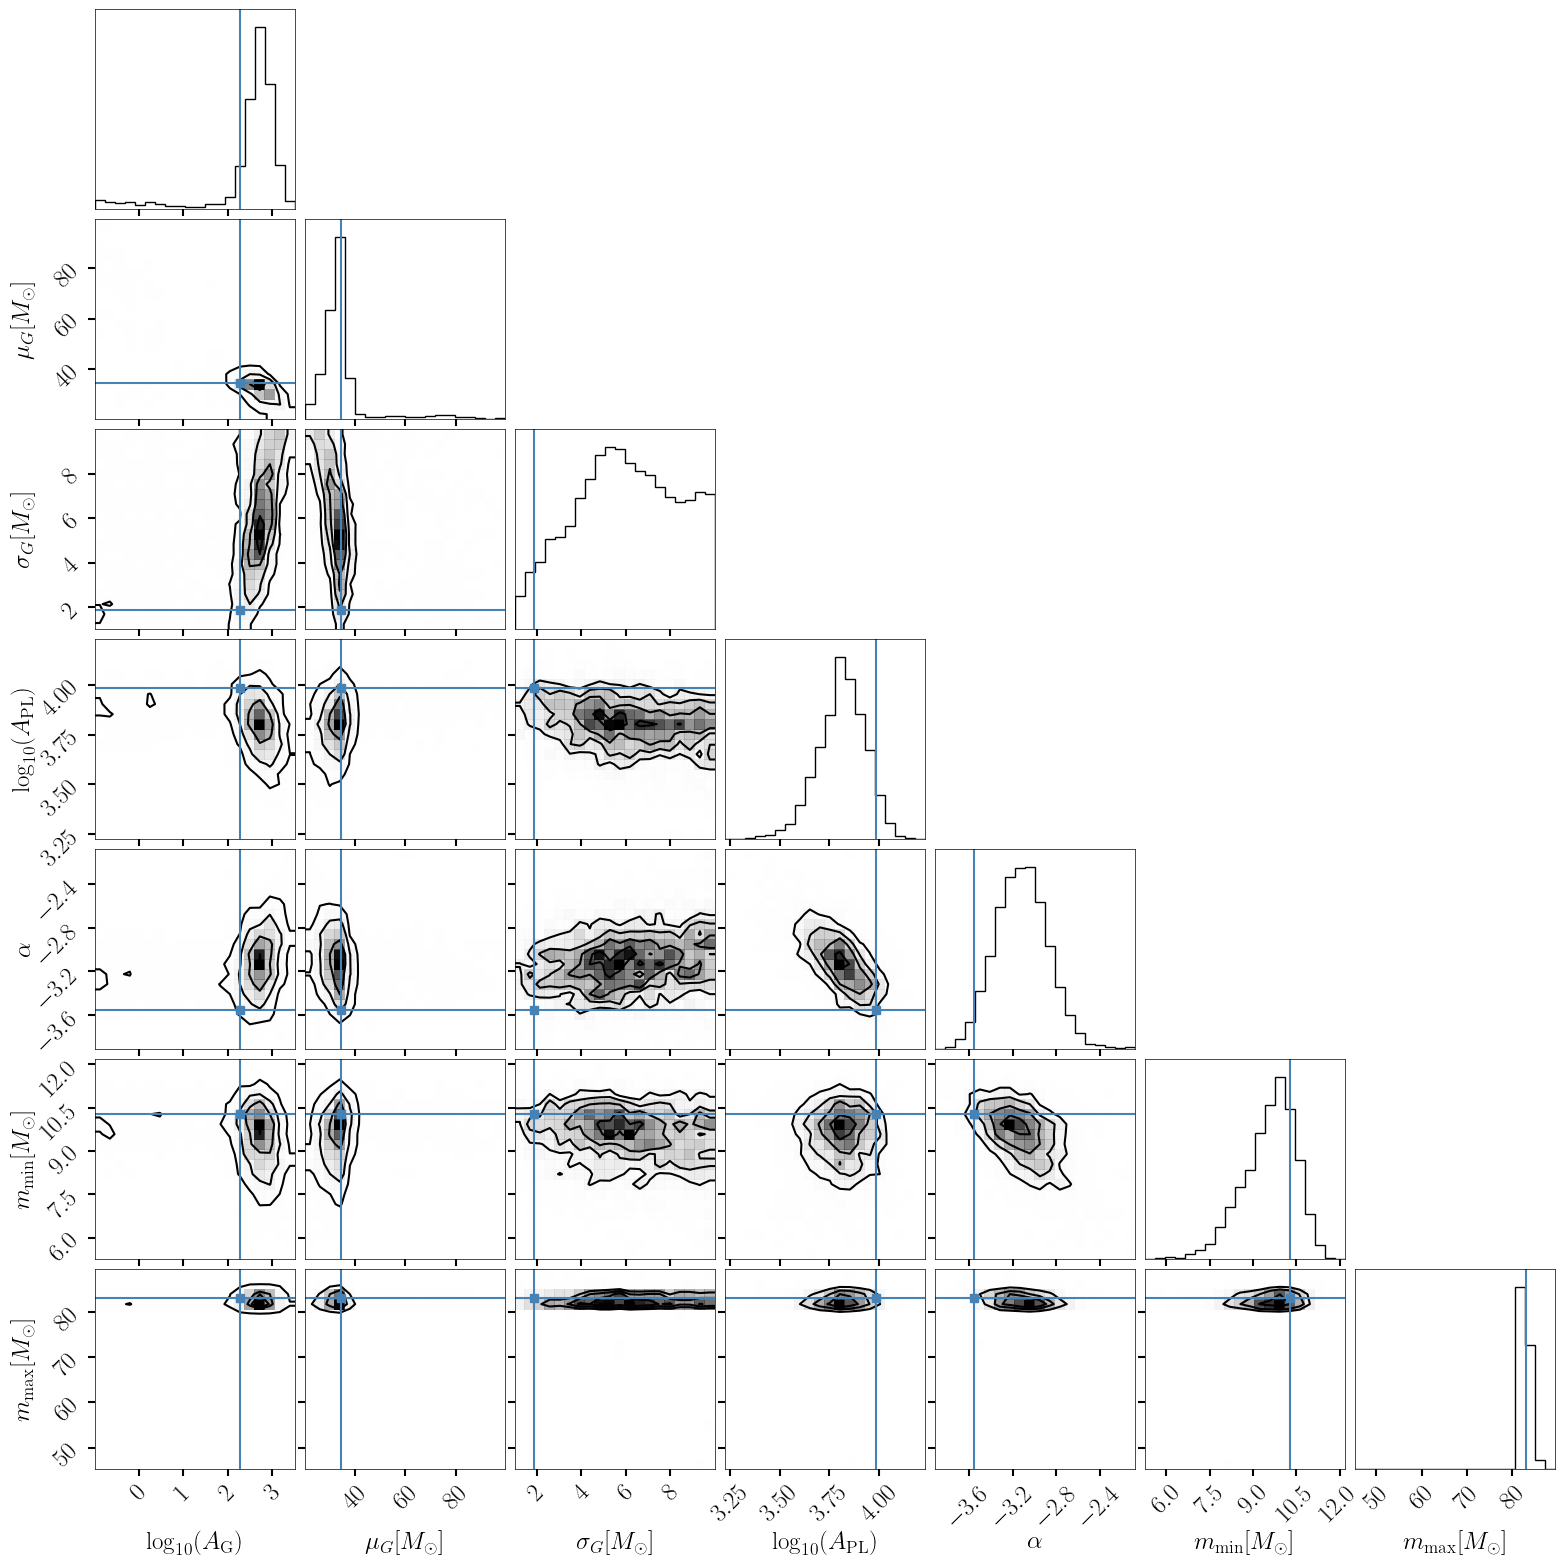

In [73]:
p0=[np.log10(params_gauss_true['ampl'][0,0]*len(m1s_true)),params_gauss_true['mu'][0,0],params_gauss_true['sigma'][0,0],np.log10(params_pl_true['ampl'][0,0]*len(m1s_true)),params_pl_true['alpha'][0,0],params_pl_true['mmin'][0,0],params_pl_true['mmax'][0,0]]

labels=['$\\log_{10}(A_{\\rm G})$','$\\mu_G[M_{\\odot}]$','$\\sigma_G[M_{\\odot}]$','$\\log_{10}(A_{\\rm PL})$','$\\alpha$','$m_{\\rm min}[M_{\\odot}]$','$m_{\\rm max}[M_{\\odot}]$']
print(p0)
corner.corner(samples_all,truths=p0,plot_datapoints=False,labels=labels)